<a href="https://colab.research.google.com/github/yogesh-bhattarai/Django/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark

In [3]:
import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("yogesh machine learning") \
                            .master("local[*]")\
                            .config("spark.some.config.option", "some-value") \
                            .getOrCreate()


In [14]:
df = spark.read.csv(
    "/content/Airline_Delay_Cause.csv",
    header=True,
    inferSchema=True
)

In [15]:
df.printSchema()

root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- carrier: string (nullable = true)
 |-- carrier_name: string (nullable = true)
 |-- airport: string (nullable = true)
 |-- airport_name: string (nullable = true)
 |-- arr_flights: integer (nullable = true)
 |-- arr_del15: integer (nullable = true)
 |-- carrier_ct: double (nullable = true)
 |-- weather_ct: double (nullable = true)
 |-- nas_ct: double (nullable = true)
 |-- security_ct: double (nullable = true)
 |-- late_aircraft_ct: double (nullable = true)
 |-- arr_cancelled: integer (nullable = true)
 |-- arr_diverted: integer (nullable = true)
 |-- arr_delay: integer (nullable = true)
 |-- carrier_delay: integer (nullable = true)
 |-- weather_delay: integer (nullable = true)
 |-- nas_delay: integer (nullable = true)
 |-- security_delay: integer (nullable = true)
 |-- late_aircraft_delay: integer (nullable = true)



In [16]:
df.show(5)

+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier| carrier_name|airport|        airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|2025|    1|     G4|Allegiant Air|    ELM|Elmira/Corning, N...|         30|        0|       0.0|       0.0|   0.0|        0.0|             0.0|            0|           0|        0|            0|            0|        0|             0|     

In [45]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

Null value check

In [18]:
null_counts = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
])

null_counts.show()

+----+-----+-------+------------+-------+------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier|carrier_name|airport|airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+------------+-------+------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|   0|    0|      0|           0|      0|           0|        657|      950|       657|       657|   657|        657|             657|          657|         657|      657|          657|          657|      657|           657|                657|
+----+-----+-------+

imputation

In [19]:
numeric_cols = [
    'arr_flights',
    'arr_del15',
    'carrier_ct',
    'weather_ct',
    'nas_ct',
    'security_ct',
    'late_aircraft_ct'
]

df = df.fillna(0, subset=numeric_cols)

Remove Invalid Records

In [20]:
df = df.filter(col("arr_flights") > 0)

Simple Outlier Rule

In [21]:
df = df.filter(col("arr_del15") <= col("arr_flights"))

In [25]:
df.show(10)

+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier| carrier_name|airport|        airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|2025|    1|     G4|Allegiant Air|    ELM|Elmira/Corning, N...|         30|        0|       0.0|       0.0|   0.0|        0.0|             0.0|            0|           0|        0|            0|            0|        0|             0|     

2. How Have Overall Flight Delays Changed Over Time?

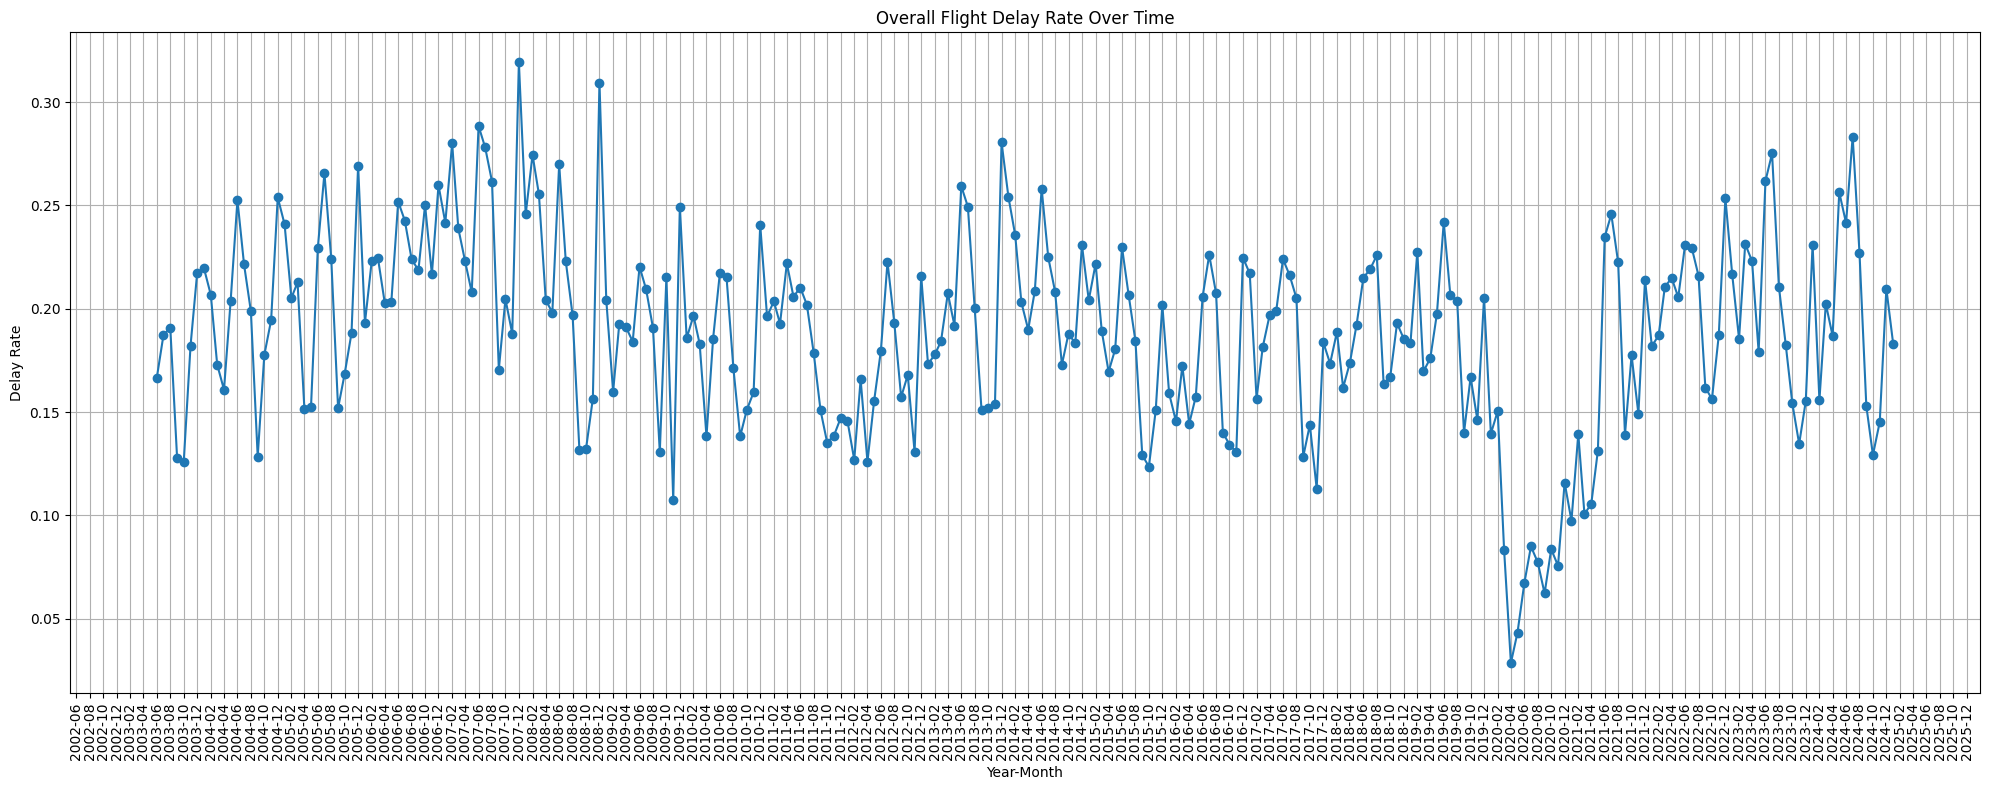

In [43]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates  # 1. Import the dates module

# Delay trend by Year-Month
delay_trend = df.groupBy("year", "month") \
    .agg(
        sum("arr_del15").alias("total_delays"),
        sum("arr_flights").alias("total_flights")
    ) \
    .withColumn(
        "delay_rate",
        col("total_delays") / col("total_flights")
    ) \
    .orderBy("year", "month")

delay_pd = delay_trend.toPandas()

# 2. Convert to datetime format instead of a plain string
delay_pd["period"] = pd.to_datetime(
    delay_pd["year"].astype(str) + "-" + delay_pd["month"].astype(str)
)

# Plot
plt.figure(figsize=(20,8))
plt.plot(delay_pd["period"],
         delay_pd["delay_rate"],
         marker='o')

# 3. Format and space out the X-axis labels dynamically
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Forces 'YYYY-MM' format
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # Adjust interval (e.g., show a tick every 2 months)

plt.xticks(rotation=90)  # 45 degrees is often easier to read than 90
plt.title("Overall Flight Delay Rate Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Delay Rate")
plt.grid(True)

plt.tight_layout()
plt.show()

3. Which Airlines Have the Highest Percentage of Delayed Flights?

/tmp/ipykernel_3837/112184369.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


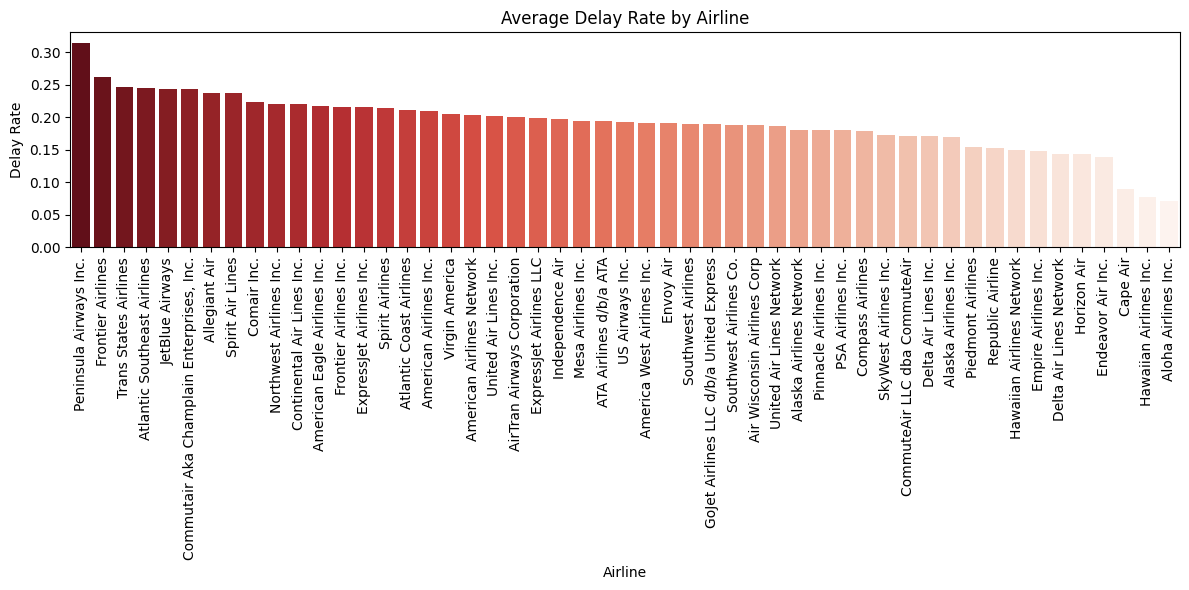

In [46]:
carrier_delay = df.groupBy("carrier_name") \
    .agg(
        sum("arr_del15").alias("delays"),
        sum("arr_flights").alias("flights")
    ) \
    .withColumn(
        "delay_rate",
        col("delays") / col("flights")
    ) \
    .orderBy(desc("delay_rate"))

carrier_pd = carrier_delay.toPandas()

plt.figure(figsize=(12,6))

sns.barplot(
    data=carrier_pd,
    x="carrier_name",
    y="delay_rate",
    palette="Reds_r"
)

plt.xticks(rotation=90)
plt.title("Average Delay Rate by Airline")
plt.xlabel("Airline")
plt.ylabel("Delay Rate")

plt.tight_layout()
plt.show()

4. Which Airlines Experience the Most Carrier-Caused Delays?

/tmp/ipykernel_3837/3087057847.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


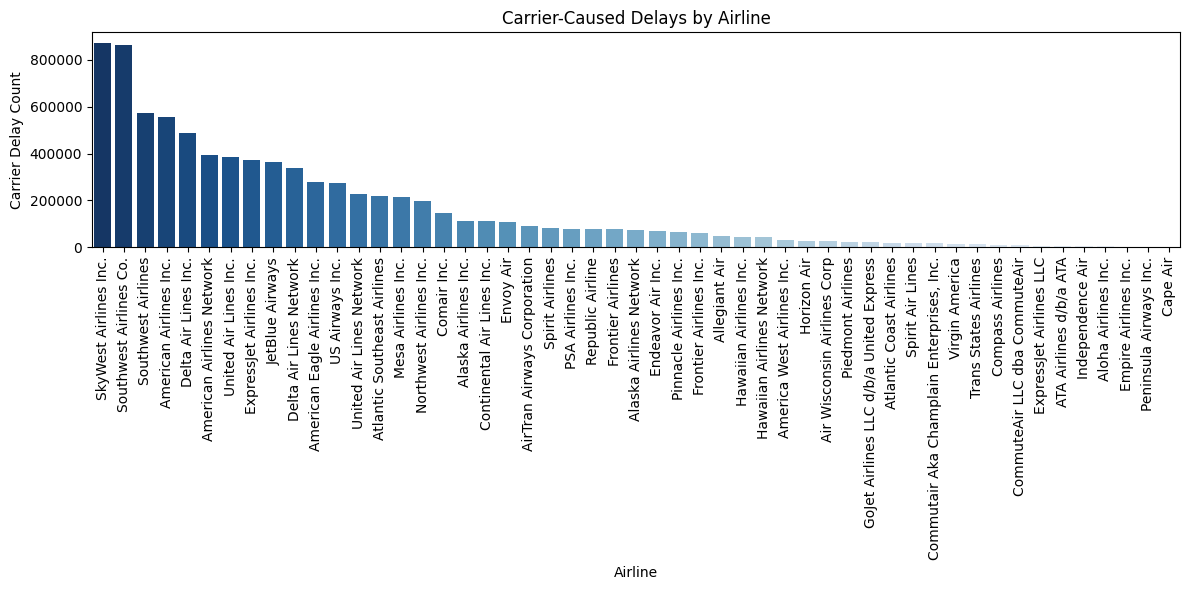

In [47]:
carrier_cause = df.groupBy("carrier_name") \
    .agg(
        sum("carrier_ct").alias("carrier_delay_count")
    ) \
    .orderBy(desc("carrier_delay_count"))

carrier_cause_pd = carrier_cause.toPandas()

plt.figure(figsize=(12,6))

sns.barplot(
    data=carrier_cause_pd,
    x="carrier_name",
    y="carrier_delay_count",
    palette="Blues_r"
)

plt.xticks(rotation=90)

plt.title("Carrier-Caused Delays by Airline")
plt.xlabel("Airline")
plt.ylabel("Carrier Delay Count")

plt.tight_layout()
plt.show()

5. Which Airports Have the Highest Delay Rates?

/tmp/ipykernel_3837/3015540825.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


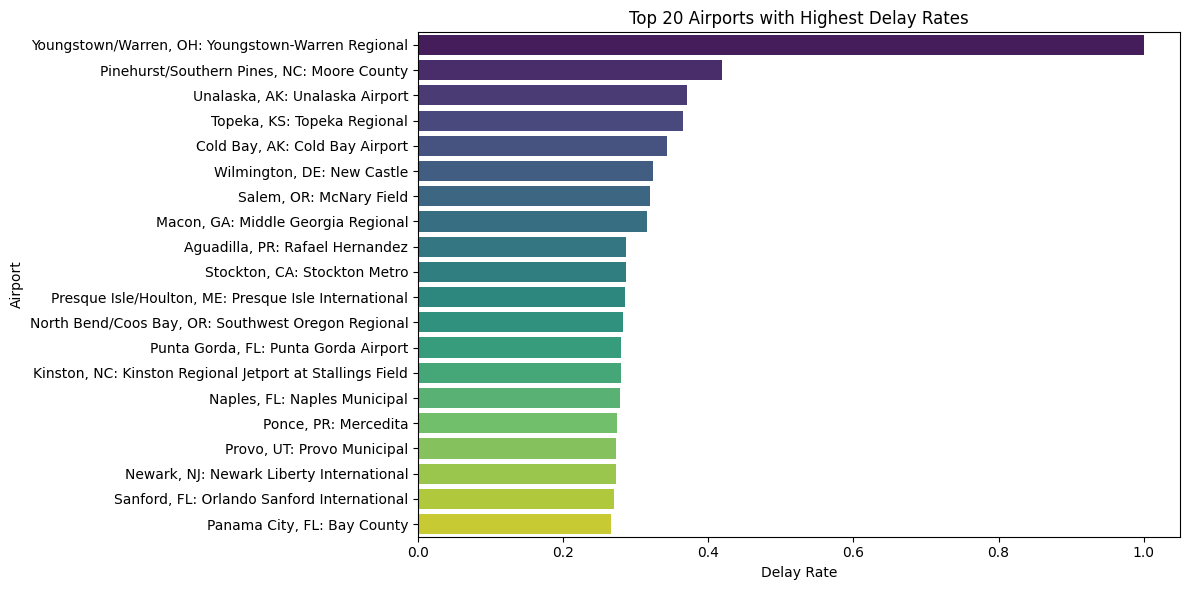

In [48]:
airport_delay = df.groupBy("airport_name") \
    .agg(
        sum("arr_del15").alias("delays"),
        sum("arr_flights").alias("flights")
    ) \
    .withColumn(
        "delay_rate",
        col("delays") / col("flights")
    ) \
    .orderBy(desc("delay_rate"))

top_airports = airport_delay.limit(20)

airport_pd = top_airports.toPandas()

plt.figure(figsize=(12,6))

sns.barplot(
    data=airport_pd,
    x="delay_rate",
    y="airport_name",
    palette="viridis"
)

plt.title("Top 20 Airports with Highest Delay Rates")
plt.xlabel("Delay Rate")
plt.ylabel("Airport")

plt.tight_layout()
plt.show()

6. What Are the Dominant Causes of Delays Across All Flights?

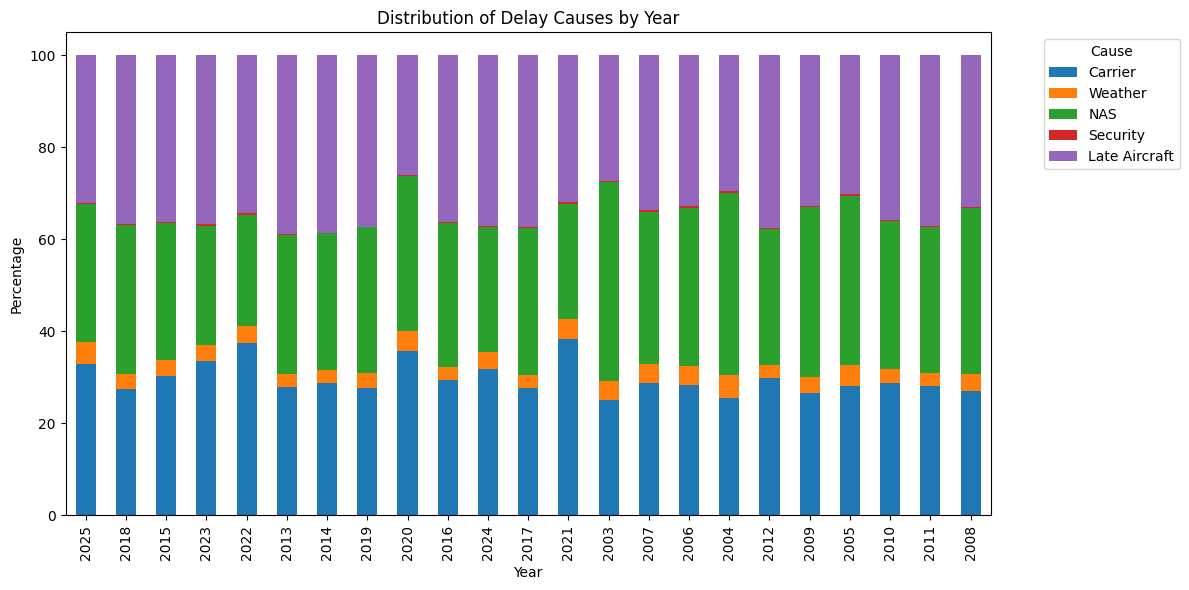

In [49]:
cause_year = df.groupBy("year").agg(
    sum("carrier_ct").alias("Carrier"),
    sum("weather_ct").alias("Weather"),
    sum("nas_ct").alias("NAS"),
    sum("security_ct").alias("Security"),
    sum("late_aircraft_ct").alias("Late Aircraft")
)

cause_pd = cause_year.toPandas()

cause_pd = cause_pd.set_index("year")
cause_pct = cause_pd.div(
    cause_pd.sum(axis=1),
    axis=0
) * 100

cause_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Distribution of Delay Causes by Year")
plt.ylabel("Percentage")
plt.xlabel("Year")

plt.legend(
    title="Cause",
    bbox_to_anchor=(1.05,1)
)

plt.tight_layout()
plt.show()

7. How Do Causes Vary by Season?

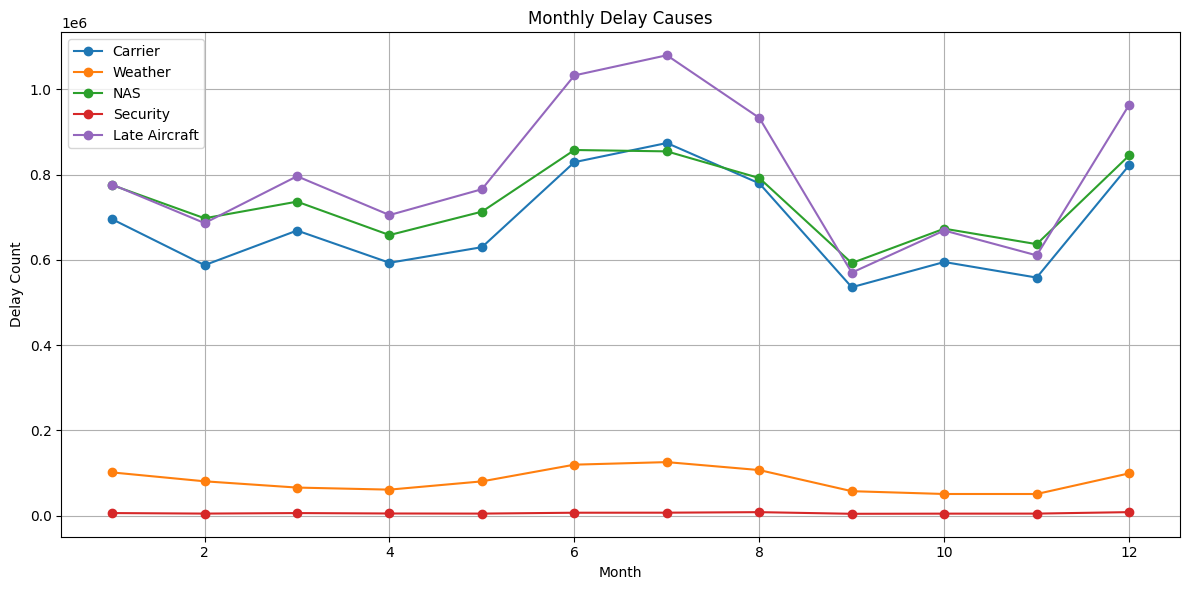

In [50]:
# -----------------------------------------------------
# Monthly delay causes
# -----------------------------------------------------

seasonal = df.groupBy("month").agg(
    sum("carrier_ct").alias("Carrier"),
    sum("weather_ct").alias("Weather"),
    sum("nas_ct").alias("NAS"),
    sum("security_ct").alias("Security"),
    sum("late_aircraft_ct").alias("Late Aircraft")
).orderBy("month")

seasonal_pd = seasonal.toPandas()

plt.figure(figsize=(12,6))

plt.plot(
    seasonal_pd["month"],
    seasonal_pd["Carrier"],
    marker='o',
    label="Carrier"
)

plt.plot(
    seasonal_pd["month"],
    seasonal_pd["Weather"],
    marker='o',
    label="Weather"
)

plt.plot(
    seasonal_pd["month"],
    seasonal_pd["NAS"],
    marker='o',
    label="NAS"
)

plt.plot(
    seasonal_pd["month"],
    seasonal_pd["Security"],
    marker='o',
    label="Security"
)

plt.plot(
    seasonal_pd["month"],
    seasonal_pd["Late Aircraft"],
    marker='o',
    label="Late Aircraft"
)

plt.title("Monthly Delay Causes")
plt.xlabel("Month")
plt.ylabel("Delay Count")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

8. Which Months Have the Highest and Lowest Delay Percentages?

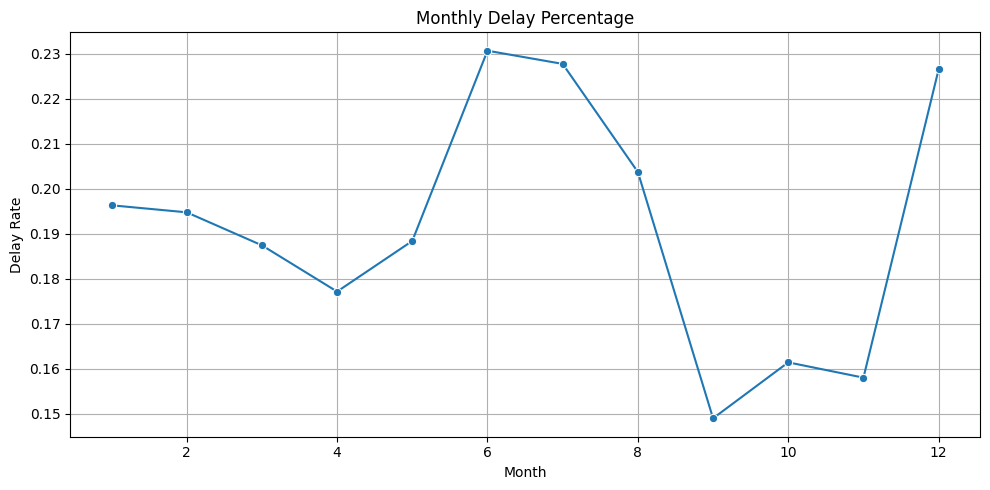

In [51]:
monthly_delay = df.groupBy("month") \
    .agg(
        sum("arr_del15").alias("delays"),
        sum("arr_flights").alias("flights")
    ) \
    .withColumn(
        "delay_rate",
        col("delays") / col("flights")
    ) \
    .orderBy("month")

monthly_pd = monthly_delay.toPandas()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_pd,
    x="month",
    y="delay_rate",
    marker="o"
)

plt.title("Monthly Delay Percentage")
plt.xlabel("Month")
plt.ylabel("Delay Rate")

plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
df = pd.read_csv(r'/content/PlayersDataset.csv')

/tmp/ipykernel_3837/3899136079.py:2: DtypeWarning: Columns (23,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'/content/PlayersDataset.csv')


In [7]:
df

,Unnamed: 0,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,RB,RCB,RCM,RDM,RF,RM,RS,RW,RWB,ST
0,0,Cristiano Ronaldo,32,https://cdn.sofifa.org/48/18/players/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Real Madrid CF,https://cdn.sofifa.org/24/18/teams/243.png,...,61.0,53.0,82.0,62.0,91.0,89.0,92.0,91.0,66.0,92.0
1,1,L. Messi,30,https://cdn.sofifa.org/48/18/players/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,93,93,FC Barcelona,https://cdn.sofifa.org/24/18/teams/241.png,...,57.0,45.0,84.0,59.0,92.0,90.0,88.0,91.0,62.0,88.0
2,2,Neymar,25,https://cdn.sofifa.org/48/18/players/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,94,Paris Saint-Germain,https://cdn.sofifa.org/24/18/teams/73.png,...,59.0,46.0,79.0,59.0,88.0,87.0,84.0,89.0,64.0,84.0
3,3,L. Suárez,30,https://cdn.sofifa.org/48/18/players/176580.png,Uruguay,https://cdn.sofifa.org/flags/60.png,92,92,FC Barcelona,https://cdn.sofifa.org/24/18/teams/241.png,...,64.0,58.0,80.0,65.0,88.0,85.0,88.0,87.0,68.0,88.0
4,4,M. Neuer,31,https://cdn.sofifa.org/48/18/players/167495.png,Germany,https://cdn.sofifa.org/flags/21.png,92,92,FC Bayern Munich,https://cdn.sofifa.org/24/18/teams/21.png,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17976,17976,A. Kelsey,17,https://cdn.sofifa.org/48/18/players/237463.png,England,https://cdn.sofifa.org/flags/14.png,46,63,Scunthorpe United,https://cdn.sofifa.org/24/18/teams/1949.png,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17977,17977,B. Richardson,47,https://cdn.sofifa.org/48/18/players/11728.png,England,https://cdn.sofifa.org/flags/14.png,46,46,Wycombe Wanderers,https://cdn.sofifa.org/24/18/teams/1933.png,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17978,17978,J. Young,17,https://cdn.sofifa.org/48/18/players/231381.png,Scotland,https://cdn.sofifa.org/flags/42.png,46,61,Swindon Town,https://cdn.sofifa.org/24/18/teams/1934.png,...,31.0,28.0,38.0,29.0,45.0,42.0,45.0,44.0,32.0,45.0
17979,17979,J. Lundstram,18,https://cdn.sofifa.org/48/18/players/238813.png,England,https://cdn.sofifa.org/flags/14.png,46,64,Crewe Alexandra,https://cdn.sofifa.org/24/18/teams/121.png,...,47.0,46.0,45.0,47.0,43.0,45.0,41.0,44.0,46.0,41.0


In [8]:
df.head(5)

,Unnamed: 0,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,RB,RCB,RCM,RDM,RF,RM,RS,RW,RWB,ST
0,0,Cristiano Ronaldo,32,https://cdn.sofifa.org/48/18/players/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Real Madrid CF,https://cdn.sofifa.org/24/18/teams/243.png,...,61.0,53.0,82.0,62.0,91.0,89.0,92.0,91.0,66.0,92.0
1,1,L. Messi,30,https://cdn.sofifa.org/48/18/players/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,93,93,FC Barcelona,https://cdn.sofifa.org/24/18/teams/241.png,...,57.0,45.0,84.0,59.0,92.0,90.0,88.0,91.0,62.0,88.0
2,2,Neymar,25,https://cdn.sofifa.org/48/18/players/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,94,Paris Saint-Germain,https://cdn.sofifa.org/24/18/teams/73.png,...,59.0,46.0,79.0,59.0,88.0,87.0,84.0,89.0,64.0,84.0
3,3,L. Suárez,30,https://cdn.sofifa.org/48/18/players/176580.png,Uruguay,https://cdn.sofifa.org/flags/60.png,92,92,FC Barcelona,https://cdn.sofifa.org/24/18/teams/241.png,...,64.0,58.0,80.0,65.0,88.0,85.0,88.0,87.0,68.0,88.0
4,4,M. Neuer,31,https://cdn.sofifa.org/48/18/players/167495.png,Germany,https://cdn.sofifa.org/flags/21.png,92,92,FC Bayern Munich,https://cdn.sofifa.org/24/18/teams/21.png,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.shape

(17981, 75)

In [10]:
df.isnull().sum()

,0
Unnamed: 0,0
Name,0
Age,0
Photo,0
Nationality,0
...,...
RM,2029
RS,2029
RW,2029
RWB,2029
